# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">Import libraries</div></center>


<style>
/* Container styling */
.report-container {
    font-family: 'Trebuchet MS', sans-serif;
    line-height: 1.6;
    color: #333;
    max-width: 900px;
    margin: auto;
}

/* Section headers */
.report-container h2 {
    background-color: #1DA1F2;
    color: #fff;
    padding: 12px;
    border-radius: 8px;
}

/* Tables */
.report-container table {
    border-collapse: collapse;
    width: 100%;
    margin-bottom: 20px;
}

.report-container th, .report-container td {
    border: 1px solid #ddd;
    padding: 10px;
    text-align: center;
}

.report-container th {
    background-color: #1DA1F2;
    color: #fff;
}

.report-container tr:nth-child(even) {
    background-color: #f2f2f2;
}

/* Highlight metrics */
.metric {
    font-weight: bold;
    color: #1DA1F2;
}

/* Confusion matrix styling */
.confusion-matrix {
    display: grid;
    grid-template-columns: repeat(3, 100px);
    grid-gap: 10px;
    justify-content: center;
    margin-top: 20px;
}

.confusion-matrix div {
    padding: 20px;
    text-align: center;
    border-radius: 8px;
    color: white;
}

.cm-positive { background-color: #4CAF50; }   /* Green */
.cm-negative { background-color: #FF9800; }   /* Orange */
.cm-neutral { background-color: #2196F3; }    /* Blue */
</style>

<div class="report-container">

<h2>1️⃣ Problem Explanation</h2>
<p><strong>Objective:</strong> Classify Twitter messages about a given entity into <span class="metric">Positive</span>, <span class="metric">Negative</span>, or <span class="metric">Neutr


In [1]:
# --- Basic Imports ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import string
import re
from collections import Counter
from tensorflow.keras.models import load_model
# --- For Preprocessing ---
import nltk
# Download necessary NLTK data (only needs to be done once)
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# --- For Splitting Data ---
from sklearn.model_selection import train_test_split

# --- For Progress Bars ---
from tqdm import tqdm

# Set a seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

2025-09-16 21:58:22.904846: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758059903.099412      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758059903.152615      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">Load and Preproces the Data</div></center>


In [2]:
# This code is updated for the "Twitter Entity Sentiment Analysis" dataset.
try:
    # Define the correct file path for the new dataset on Kaggle
    filepath = '/kaggle/input/twitter-entity-sentiment-analysis/twitter_training.csv'
    
    # Read the CSV file, which has no header
    df = pd.read_csv(filepath, header=None)
    
    # Assign meaningful column names
    df.columns = ['tweet_id', 'entity', 'sentiment', 'text']
    
    # The model we are building is a binary classifier (positive/negative),
    # so we will filter out the  and 'Irrelevant' sentiments.
    df = df[df['sentiment'].isin(['Positive', 'Negative','Neutral'])]
    
    # We only need the text and sentiment columns for our model
    df = df[['text', 'sentiment']]
    
    # Convert sentiment labels from strings to numbers (1 for Positive, 0 for Negative)
    df['sentiment'] = df['sentiment'].map({'Positive': 1, 'Negative': 0,'Neutral':2})
    
    # Drop rows with missing text, as they cannot be processed
    df.dropna(subset=['text'], inplace=True)

except FileNotFoundError:
    print("Dataset not found. Please check the file path in your Kaggle environment.")
    # Create a dummy dataframe for demonstration purposes if the file is not found
    data = {'text': ["I love this movie, it's so great!", "I hate this, it's the worst thing ever.", "It was an okay film.", "Absolutely fantastic!"],
            'sentiment': [1, 0, 1, 1]}
    df = pd.DataFrame(data)

print("Dataset loaded and prepared successfully!")
print("\nFirst 5 rows of the prepared data:")
print(df.sample(5, random_state=5))
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

Dataset loaded and prepared successfully!

First 5 rows of the prepared data:
                                                    text  sentiment
316    This latest April patch + mini DLC for Ultimat...          1
59060  CAUSE WHY ACTUAL "ACTUAL CHECKERS" RECEIVED ST...          0
26132  My friends. The drawing of prizes will take pl...          2
15147               Your tattoo is amazing!! I LOVE YOUU          1
71264  @ GhostRecon that the slide for break point is...          0

Sentiment distribution:
sentiment
0    22358
1    20655
2    18108
Name: count, dtype: int64


In [3]:
# This code is updated for the "Twitter Entity Sentiment Analysis" dataset.
try:
    # Define the correct file path for the new dataset on Kaggle
    filepath = '//kaggle/input/twitter-entity-sentiment-analysis/twitter_validation.csv'
    
    # Read the CSV file, which has no header
    df_val = pd.read_csv(filepath, header=None)
    
    # Assign meaningful column names
    df_val.columns = ['tweet_id', 'entity', 'sentiment', 'text']
    
    # The model we are building is a binary classifier (positive/negative),
    # so we will filter out the 'Neutral' and 'Irrelevant' sentiments.
    df_val = df_val[df_val['sentiment'].isin(['Positive', 'Negative','Neutral'])]
    
    # We only need the text and sentiment columns for our model
    df_val = df_val[['text', 'sentiment']]
    
    # Convert sentiment labels from strings to numbers (1 for Positive, 0 for Negative)
    df_val['sentiment'] = df_val['sentiment'].map({'Positive': 1, 'Negative': 0,'Neutral':2})
    
    # Drop rows with missing text, as they cannot be processed
    df_val.dropna(subset=['text'], inplace=True)

except FileNotFoundError:
    print("Dataset not found. Please check the file path in your Kaggle environment.")
    # Create a dummy dataframe for demonstration purposes if the file is not found
    data = {'text': ["I love this movie, it's so great!", "I hate this, it's the worst thing ever.", "It was an okay film.", "Absolutely fantastic!"],
            'sentiment': [1, 0, 1, 1]}
    df = pd.DataFrame(data)

print("Dataset loaded and prepared successfully!")
print("\nFirst 5 rows of the prepared data:")
print(df_val.sample(5, random_state=5))
print("\nSentiment distribution:")
print(df_val['sentiment'].value_counts())

Dataset loaded and prepared successfully!

First 5 rows of the prepared data:
                                                  text  sentiment
965  I FINALLY finished Borderlands 3! It's taken a...          1
941  It’s ridiculous and embarrassing how unplayabl...          0
373  Fuck buying one for my man I’m gonna buy one f...          1
338  eSports: Curiosities you probably didn’t know ...          2
971  Why didn’t anyone think of this acronym for BL...          0

Sentiment distribution:
sentiment
2    285
1    277
0    266
Name: count, dtype: int64


In [4]:
sample_sentences = [
    "This is a GREAT movie!! I loved it :)",
    "Ugh, what a horrible film. So boring...",
    "Watching this made my day! #blessed",
]

In [5]:
def normalize_text(text):
    """
    A function to clean a single piece of text.
    1. Lowercase the text
    2. Remove URLs
    3. Remove HTML tags
    4. Remove punctuation
    5. Remove numbers
    6. Remove extra whitespace
    """
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra whitespace
    return text

normalized_sentences = [normalize_text(s) for s in sample_sentences]
print("--- Original Sentences ---")
print(sample_sentences)
print("\n--- Normalized Sentences ---")
print(normalized_sentences)

--- Original Sentences ---
['This is a GREAT movie!! I loved it :)', 'Ugh, what a horrible film. So boring...', 'Watching this made my day! #blessed']

--- Normalized Sentences ---
['this is a great movie i loved it', 'ugh what a horrible film so boring', 'watching this made my day blessed']


In [6]:
df['normalized']= df['text'].apply(normalize_text)

In [7]:
df_val['normalized']= df_val['text'].apply(normalize_text)
df_val

,text,sentiment,normalized
1,BBC News - Amazon boss Jeff Bezos rejects clai...,2,bbc news amazon boss jeff bezos rejects claims...
2,@Microsoft Why do I pay for WORD when it funct...,0,microsoft why do i pay for word when it functi...
3,"CSGO matchmaking is so full of closet hacking,...",0,csgo matchmaking is so full of closet hacking ...
4,Now the President is slapping Americans in the...,2,now the president is slapping americans in the...
5,Hi @EAHelp I’ve had Madeleine McCann in my cel...,0,hi eahelp ive had madeleine mccann in my cella...
...,...,...,...
993,Please explain how this is possible! How can t...,0,please explain how this is possible how can th...
994,Good on Sony. As much as I want to see the new...,1,good on sony as much as i want to see the new ...
997,Today sucked so it’s time to drink wine n play...,1,today sucked so its time to drink wine n play ...
998,Bought a fraction of Microsoft today. Small wins.,1,bought a fraction of microsoft today small wins


# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">NLP Steps (Tokinaization ,....)</div></center>


In [8]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle as pk
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences,to_categorical
from keras.models import Sequential
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [9]:
train_text= df.normalized    
train_y= df.sentiment
val_text= df_val.normalized
val_y=df_val.sentiment

In [10]:
max_words = 20000  
max_len = 200      
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train_text)

In [11]:
import pickle

# After you fit your tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


In [12]:
X_train_seq = tokenizer.texts_to_sequences(train_text)
X_val_seq = tokenizer.texts_to_sequences(val_text)

In [13]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len)
y_train_cat = to_categorical(train_y, num_classes=3)
y_val_cat = to_categorical(val_y, num_classes=3)

# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">The LSTM Model</div></center>


In [14]:


model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1758059919.734813      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('twweter_best.keras', monitor='val_loss', save_best_only=True)
history = model.fit(X_train_pad, y_train_cat, 
                    validation_data=(X_val_pad,y_val_cat), 
                    epochs=20, 
                    batch_size=32, 
                    callbacks=[early_stop, checkpoint])

Epoch 1/20


I0000 00:00:1758059924.834713      58 cuda_dnn.cc:529] Loaded cuDNN version 90300


1911/1911 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.6487 - loss: 0.7625 - val_accuracy: 0.9420 - val_loss: 0.1910
Epoch 2/20
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9009 - loss: 0.2543 - val_accuracy: 0.9457 - val_loss: 0.1686
Epoch 3/20
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9362 - loss: 0.1626 - val_accuracy: 0.9722 - val_loss: 0.1244
Epoch 4/20
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9497 - loss: 0.1198 - val_accuracy: 0.9686 - val_loss: 0.1398
Epoch 5/20
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9568 - loss: 0.0971 - val_accuracy: 0.9674 - val_loss: 0.1362
Epoch 6/20
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.9623 - loss: 0.0842 - val_accuracy: 0.9710 - val_loss: 0.1689
Epoch 7/20
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.9672 - loss: 0.0728 - val_accuracy: 0.9746 - val_loss: 0.1796
Epoch 8/20
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.9682 - loss: 0.06

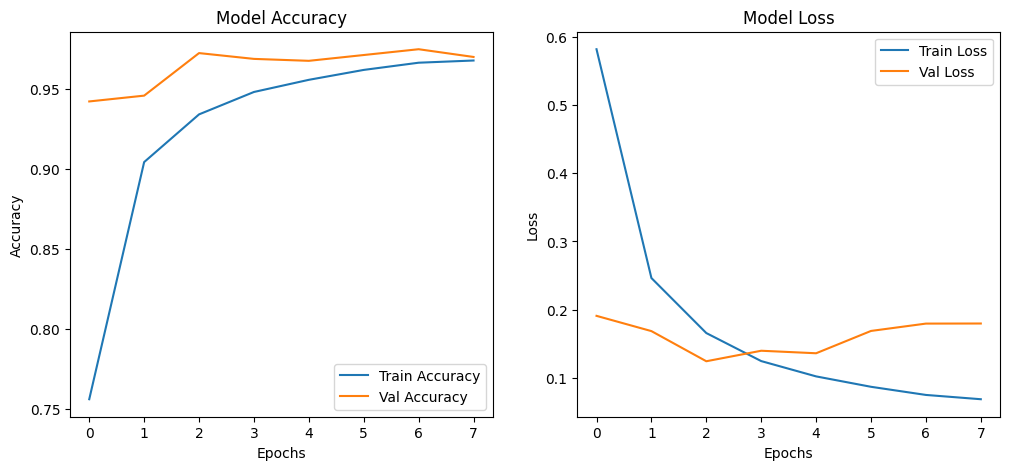

In [16]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# <center><div style="font-family: Trebuchet MS; background-color: #F93822; color: #FDD20E; padding: 12px; line-height: 1;">The Evaluation and Metrics </div></center>


In [17]:

val_loss, val_acc = model.evaluate(X_val_pad,y_val_cat)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9703 - loss: 0.1123
Validation Accuracy: 0.9722
Validation Loss: 0.1244


In [18]:
pred_probs = model.predict(X_val_pad)
y_pred = np.argmax(pred_probs, axis=1)
y_pred[:10]

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([2, 0, 0, 2, 0, 1, 1, 1, 0, 1])

In [19]:
class_name=['Negative','Positive','Neutral']

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


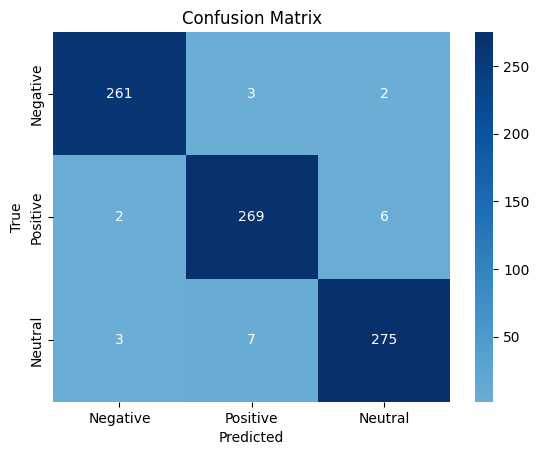

array([[261,   3,   2],
       [  2, 269,   6],
       [  3,   7, 275]])

In [20]:
CM = confusion_matrix(val_y, y_pred)
sns.heatmap(CM,annot=True,fmt='g',center = True,cmap='Blues', xticklabels=class_name, yticklabels=class_name)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
CM

In [21]:
ClassificationReport = classification_report(val_y,y_pred,target_names=class_name)
print('Classification Report is : ', ClassificationReport )

Classification Report is :                precision    recall  f1-score   support

    Negative       0.98      0.98      0.98       266
    Positive       0.96      0.97      0.97       277
     Neutral       0.97      0.96      0.97       285

    accuracy                           0.97       828
   macro avg       0.97      0.97      0.97       828
weighted avg       0.97      0.97      0.97       828



In [22]:
# import gradio as gr
# import numpy as np
# import re
# import pickle
# from tensorflow.keras.models import load_model
# from keras.utils import pad_sequences
# import matplotlib.pyplot as plt

# # ---------------- Load Model & Tokenizer ----------------
# # Load tokenizer (assuming you saved it before training)
# with open("tokenizer.pkl", "rb") as f:
#     tokenizer = pickle.load(f)


# max_len = 200
# class_names = ["Negative", "Positive", "Neutral"]
# model= load_model("/kaggle/input/kearsssstamentttt/keras/default/1/twweter_best.keras")
# # ---------------- Preprocessing ----------------
# def normalize_text(text):
#     text = text.lower()
#     text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
#     text = re.sub(r'<.*?>', '', text)  # Remove HTML
#     text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
#     text = re.sub(r'\d+', '', text)  # Remove numbers
#     text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
#     return text

# # ---------------- Prediction ----------------
# def predict_sentiment(text):
#     norm_text = normalize_text(text)
#     seq = tokenizer.texts_to_sequences([norm_text])
#     pad = pad_sequences(seq, maxlen=max_len)
#     pred = model.predict(pad)[0]
#     pred_class = np.argmax(pred)
    
#     prediction = class_names[pred_class]
#     confidence = {class_names[i]: float(pred[i]) for i in range(len(class_names))}
    
#     # Sort by confidence
#     confidence_sorted = sorted(confidence.items(), key=lambda x: x[1], reverse=True)
    
#     # Create a bar chart
#     fig, ax = plt.subplots()
#     ax.bar([c[0] for c in confidence_sorted], [c[1] for c in confidence_sorted], color=["#ef476f","#06d6a0","#118ab2"])
#     ax.set_ylim([0,1])
#     ax.set_ylabel("Confidence")
#     ax.set_title("Confidence Scores")
    
#     return prediction, confidence_sorted, fig

# # ---------------- CSS Styling ----------------
# CUSTOM_CSS = """
# .gradio-container {
#     background: linear-gradient(135deg, #f8f9fa, #e9ecef);
#     font-family: 'Segoe UI', Tahoma, sans-serif;
# }
# .gr-button {
#     background: #0077b6 !important;
#     color: white !important;
#     border-radius: 12px !important;
#     font-size: 16px !important;
#     padding: 10px 20px !important;
# }
# .gr-text-input textarea {
#     border-radius: 12px !important;
#     border: 2px solid #0077b6 !important;
#     font-size: 15px !important;
# }
# h1 {
#     text-align: center;
#     color: #023e8a;
# }
# """

# # ---------------- Gradio UI ----------------
# with gr.Blocks(css=CUSTOM_CSS) as demo:
#     gr.Markdown("<h1>🐦 Twitter Sentiment Classifier</h1>")
    
#     with gr.Row():
#         with gr.Column(scale=2):
#             input_text = gr.Textbox(
#                 label="Enter a Tweet",
#                 placeholder="Type a tweet about an entity...",
#                 lines=4
#             )
#             submit_btn = gr.Button("Classify Tweet")
        
#         with gr.Column(scale=1):
#             output_label = gr.Label(label="Prediction")
#             output_table = gr.Dataframe(
#                 headers=["Class", "Confidence"],
#                 datatype=["str", "number"],
#                 col_count=(2, "fixed"),
#                 row_count=3,
#                 label="Confidence Scores"
#             )
#             output_plot = gr.Plot(label="Confidence Bar Chart")
    
#     submit_btn.click(
#         fn=predict_sentiment,
#         inputs=input_text,
#         outputs=[output_label, output_table, output_plot]
#     )

# demo.launch()
